# 勇者傳說 — Decoration V3 Re-generator (T4 GPU)

**Auto-detect** low-quality sprites from V2 output and **re-generate** with hardened prompts.

Key improvements over V2:
- Auto-scans V2 output for quality failures (opaque%, bbox%, file size)
- Hardened prompts: more solid/opaque subjects, explicit color descriptions
- Higher gen resolution (512×512) for failed items
- More inference steps (28) and higher guidance (8.0) for difficult subjects
- Conditional bg removal: skip for items that are inherently transparent/wispy
- Up to 5 retries with different seeds

**Self-contained**: No repo clone needed.  
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`  
**Resume**: 中斷後重跑自動跳過已完成的

In [1]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

In [2]:
from PIL import Image
import numpy as np


class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')


_rmbg_model = None
_rembg_session = None


def remove_background(img):
    """Remove background using RMBG-2.0 (primary) + rembg u2net (fallback)."""
    global _rmbg_model, _rembg_session

    # Primary: RMBG-2.0
    try:
        if _rmbg_model is None:
            from transformers import pipeline
            _rmbg_model = pipeline('image-segmentation',
                                   model='briaai/RMBG-2.0',
                                   trust_remote_code=True,
                                   device=0 if torch.cuda.is_available() else -1)
        result = _rmbg_model(img)
        if isinstance(result, list):
            mask = result[0]['mask']
        else:
            mask = result['mask']
        img = img.convert('RGBA')
        img.putalpha(mask.convert('L'))
        return img
    except Exception as e:
        print(f'[warn] RMBG-2.0 failed: {e}, trying rembg...')

    # Fallback: rembg u2net
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def quality_check(img, min_opaque_pct=0.10, min_bbox_pct=0.20):
    """Check image quality: enough opaque pixels and content coverage."""
    arr = np.array(img.convert('RGBA'))
    alpha = arr[:, :, 3]
    total = alpha.size
    opaque = int(np.sum(alpha > 10))
    opaque_pct = opaque / total

    if opaque_pct < min_opaque_pct:
        print(f'[qc] low opaque {opaque_pct:.1%}', end=' ')
        return False

    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        print('[qc] empty', end=' ')
        return False
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    bbox_area = (rmax - rmin + 1) * (cmax - cmin + 1)
    bbox_pct = bbox_area / total

    if bbox_pct < min_bbox_pct:
        print(f'[qc] small bbox {bbox_pct:.1%}', end=' ')
        return False

    return True


def scan_quality(deco_dir):
    """Scan existing output dir for quality failures. Returns list of failed names."""
    fails = []
    for png in sorted(Path(deco_dir).glob('*.png')):
        if png.stem.startswith('_'):
            continue
        img = Image.open(png).convert('RGBA')
        arr = np.array(img)
        alpha = arr[:, :, 3]
        total = alpha.size
        opaque = int(np.sum(alpha > 10))
        opaque_pct = opaque / total

        issues = []
        if opaque_pct < 0.10:
            issues.append(f'low_opaque({opaque_pct:.1%})')

        rows = np.any(alpha > 10, axis=1)
        cols = np.any(alpha > 10, axis=0)
        if rows.any():
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]
            bbox_pct = ((rmax - rmin + 1) * (cmax - cmin + 1)) / total
            if bbox_pct < 0.20:
                issues.append(f'small_bbox({bbox_pct:.1%})')
        else:
            issues.append('empty')

        if opaque_pct < 0.05:
            issues.append('NEARLY_EMPTY')

        kb = png.stat().st_size / 1024
        status = 'FAIL' if issues else 'OK'
        print(f'  {png.stem:<25} {img.size[0]}x{img.size[1]}  {opaque_pct:>6.1%}  {kb:>5.0f}KB  {status}  {" ".join(issues)}')
        if issues:
            fails.append(png.stem)
    return fails

In [3]:
# ─── V3 Hardened Prompts ───
# All V2 entries + improved prompts for known failures.
# Key changes for failed items:
#   - More solid/opaque subject descriptions
#   - Explicit colors and materials
#   - Higher gen resolution (512) and steps (28)
#   - skip_bg_removal flag for inherently transparent subjects

V3_PROMPTS = {
    '_meta': {
        'style_prefix_xl': '16-bit JRPG pixel art, top-down RPG decoration object',
        'style_suffix_deco_xl': 'single object centered, transparent background, clean edges, detailed pixel art sprite',
        'negative_prompt_xl': 'blurry, modern, text, UI, photograph, realistic photo, people, characters, watermark, multiple objects',
    },
    'decorations': [
        # ─── V2 originals (kept for reference / full re-gen) ───
        # Hero kingdom
        {'name': 'deco_training_dummy', 'prompt_xl': 'wooden sword training dummy practice target, straw filled, medieval training ground equipment', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Elf kingdom
        {'name': 'deco_vine_arch', 'prompt_xl': 'living vine archway gate covered in green leaves and flowers, elven forest entrance arch', 'gen_size': 256, 'final_w': 64, 'final_h': 96, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_hanging_lantern', 'prompt_xl': 'ornate hanging lantern with warm glow, metal and glass elven style lantern on chain', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Treant kingdom
        {'name': 'deco_ancient_tree', 'prompt_xl': 'massive ancient sacred tree with glowing runes carved in bark, giant mystical oak tree, hollow trunk', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_mushroom_large', 'prompt_xl': 'giant glowing bioluminescent mushroom, spotted cap, fantasy forest mushroom, purple and blue glow', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Beast kingdom
        {'name': 'deco_fire_pit', 'prompt_xl': 'blazing stone fire pit campfire with flames, tribal stone ring bonfire, warm orange glow', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_totem', 'prompt_xl': 'tall carved wooden totem pole with animal faces, tribal spirit totem, painted colors', 'gen_size': 256, 'final_w': 64, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_arena', 'prompt_xl': 'fighting arena ground marking circle with torches, combat ring, tribal battle arena floor from above', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        # Merfolk kingdom
        {'name': 'deco_canal_bridge', 'prompt_xl': 'ornate small stone canal bridge over water, arched bridge with coral decorations, aquatic town bridge', 'gen_size': 256, 'final_w': 128, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Dwarf kingdom
        {'name': 'deco_crystal', 'prompt_xl': 'glowing crystal cluster formation, purple and blue mineral crystals growing from rock, gem deposit', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_mine_entrance_sm', 'prompt_xl': 'small mine shaft entrance in rock wall, wooden support beams, minecart track, dark tunnel opening', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},
        # Undead kingdom
        {'name': 'deco_gravestone', 'prompt_xl': 'weathered old tombstone gravestone, cracked stone with moss, cemetery headstone, eerie green glow', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Hotspring kingdom
        {'name': 'deco_bamboo_fence', 'prompt_xl': 'Japanese bamboo fence section, woven bamboo barrier, garden divider, zen style bamboo wall', 'gen_size': 256, 'final_w': 128, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_stone_lantern', 'prompt_xl': 'Japanese stone lantern toro, traditional garden stone lantern, warm light, zen garden element', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Mountain kingdom
        {'name': 'deco_prayer_flag', 'prompt_xl': 'colorful Tibetan prayer flags on string line, fluttering cloth flags, mountain temple prayer flags', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        {'name': 'deco_cairn', 'prompt_xl': 'stacked stone cairn rock pile, balanced stones trail marker, mountain path stone pile', 'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 22, 'guidance': 7.5},
        # Demon kingdom
        {'name': 'deco_rune_circle', 'prompt_xl': 'dark magical rune circle on ground, glowing red arcane symbols in circle pattern, demonic summoning circle', 'gen_size': 256, 'final_w': 128, 'final_h': 128, 'steps': 22, 'guidance': 7.5},

        # ─── V3 HARDENED: Failed items with improved prompts ───

        # deco_dock: V2 failed (3.9% opaque) — water pier blended with bg.
        # Fix: Emphasize solid brown wooden structure, no water, darker wood color.
        {'name': 'deco_dock', 'prompt_xl': 'solid brown wooden dock pier platform, thick wooden planks and posts, rope-tied bollards, heavy timber construction, dark brown oak wood, sturdy harbor pier structure, no water', 'gen_size': 512, 'final_w': 128, 'final_h': 64, 'steps': 28, 'guidance': 8.0},

        # deco_lava_vent: V2 failed (8.3% opaque) — steam/gas too transparent.
        # Fix: Emphasize solid rock formation with visible lava, not steam.
        {'name': 'deco_lava_vent', 'prompt_xl': 'volcanic rock formation with bright orange lava cracks, dark basalt stone mound with glowing magma veins, molten lava pool in cracked obsidian rock, bright red-orange glow, solid rock structure', 'gen_size': 512, 'final_w': 64, 'final_h': 64, 'steps': 28, 'guidance': 8.0},
    ],
}

# Build lookup for quick access
V3_LOOKUP = {e['name']: e for e in V3_PROMPTS['decorations']}
print(f'V3 prompt entries: {len(V3_PROMPTS["decorations"])}')
print(f'Hardened entries (512px, 28 steps): {sum(1 for e in V3_PROMPTS["decorations"] if e["gen_size"] == 512)}')

V3 prompt entries: 19
Hardened entries (512px, 28 steps): 2


In [4]:
# ─── Auto-detect failures from V2 output ───
deco_dir = OUTPUT_BASE / 'decorations'
if deco_dir.exists():
    print('=== Scanning V2 output for quality failures ===')
    auto_fails = scan_quality(deco_dir)
    print(f'\nAuto-detected failures: {auto_fails}')
else:
    print('No V2 output found — will generate all entries')
    auto_fails = [e['name'] for e in V3_PROMPTS['decorations']]

# Also include any V3 hardened entries that don't exist yet
missing = [e['name'] for e in V3_PROMPTS['decorations']
           if not (deco_dir / f"{e['name']}.png").exists()]
print(f'Missing files: {missing}')

# Combine: failures + missing = items to regenerate
to_regen = sorted(set(auto_fails + missing))
print(f'\nTotal to regenerate: {len(to_regen)}')
for name in to_regen:
    entry = V3_LOOKUP.get(name)
    if entry:
        hardened = ' [HARDENED]' if entry['gen_size'] == 512 else ''
        print(f'  {name} ({entry["final_w"]}x{entry["final_h"]}, {entry["steps"]} steps){hardened}')
    else:
        print(f'  {name} (no V3 prompt — skipping)')

=== Scanning V2 output for quality failures ===
  deco_ancient_tree         128x128   30.4%     13KB  OK  
  deco_arena                128x128   49.6%     13KB  OK  
  deco_bamboo_fence         128x64   21.2%      5KB  OK  
  deco_cairn                64x64   41.4%      5KB  OK  
  deco_canal_bridge         128x64   18.4%      3KB  OK  
  deco_crystal              64x64   58.8%      7KB  OK  
  deco_dock                 128x64    3.9%      2KB  FAIL  low_opaque(3.9%) small_bbox(13.5%) NEARLY_EMPTY
  deco_fire_pit             64x64   47.2%      6KB  OK  
  deco_gravestone           64x64   37.4%      4KB  OK  
  deco_hanging_lantern      64x64   28.9%      4KB  OK  
  deco_lava_vent            64x64    8.3%      4KB  FAIL  low_opaque(8.3%)
  deco_mine_entrance_sm     128x128   27.7%     14KB  OK  
  deco_mushroom_large       64x64   35.9%      5KB  OK  
  deco_prayer_flag          64x64   21.9%      4KB  OK  
  deco_rune_circle          128x128   31.1%     12KB  OK  
  deco_stone_lanter

In [ ]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE})...')
t0 = time.time()

# kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True}
kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

# low_cpu_mem_usage=False avoids "Cannot copy out of meta tensor" when loading
# from a locally cached model (saved via save_pretrained)
pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.85])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.85)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

[pipeline] Loading SDXL (cuda)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Some weights of the model checkpoint at /content/drive/MyDrive/ai-rpg-game/models/stable-diffusion-xl-base-1.0/unet were not used when initializing UNet2DConditionModel: 
 ['up_blocks.0.attentions.0.transformer_blocks.7.attn1.to_out.0.lora_A.pixel_xl.weight, up_blocks.1.attentions.1.transformer_blocks.1.attn2.to_v.base_layer.weight, mid_block.attentions.0.transformer_blocks.6.attn2.to_v.lora_A.pixel_xl.weight, up_blocks.0.attentions.2.transformer_blocks.9.attn1.to_q.lora_B.pixel_xl.weight, mid_block.attentions.0.transformer_blocks.8.attn1.to_v.lora_A.pixel_xl.weight, down_blocks.2.attentions.1.transformer_blocks.1.attn2.to_k.lora_A.pixel_xl.weight, mid_block.attentions.0.transformer_blocks.4.attn2.to_q.base_layer.weight, down_blocks.1.attentions.1.transformer_blocks.0.ff.net.2.lora_B.pixel_xl.weight, down_blocks.1.attentions.0.transformer_blocks.0.attn1.to_v.base_layer.weight, down_blocks.2.attentions.0.transformer_blocks.2.attn2.to_k.base_layer.weight, up_blocks.0.attentions.1.transfo

pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.85)
[pipeline] Ready in 42.8s
[vram] 8.3/14.6 GB


In [7]:
def postprocess_deco(img, entry):
    """Remove background, crop, resize to target size."""
    final_w = entry['final_w']
    final_h = entry['final_h']

    img = remove_background(img.convert('RGBA'))

    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows_mask = np.any(alpha > 10, axis=1)
    cols_mask = np.any(alpha > 10, axis=0)
    if not rows_mask.any():
        return img.resize((final_w, final_h), Image.NEAREST)

    rmin, rmax = np.where(rows_mask)[0][[0, -1]]
    cmin, cmax = np.where(cols_mask)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    cw, ch = cropped.size
    scale = min(final_w / cw, final_h / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    canvas = Image.new('RGBA', (final_w, final_h), (0, 0, 0, 0))
    x = (final_w - new_w) // 2
    y = final_h - new_h  # bottom-align
    canvas.paste(resized, (x, y))
    return canvas


# ─── Re-generate failed/missing items ───
out_dir = OUTPUT_BASE / 'decorations'
out_dir.mkdir(parents=True, exist_ok=True)
meta = V3_PROMPTS['_meta']

tracker = ProgressTracker('decorations_v3', OUTPUT_BASE)

regen_entries = [V3_LOOKUP[n] for n in to_regen if n in V3_LOOKUP]
remaining = sum(1 for e in regen_entries if not tracker.is_done(e['name']))
print(f'\nV3 Re-generation: {len(regen_entries)} entries, {remaining} remaining')

MAX_RETRIES = 5  # more retries for hardened items

for i, entry in enumerate(regen_entries):
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name):
        print(f'  [skip] {name}')
        continue

    prefix = meta['style_prefix_xl']
    suffix = meta['style_suffix_deco_xl']
    neg = meta['negative_prompt_xl']
    prompt = f"{prefix}, {entry['prompt_xl']}, {suffix}"

    gen_size = entry['gen_size']
    hardened = gen_size == 512
    tag = ' [HARDENED]' if hardened else ''
    print(f"[{i+1}/{len(regen_entries)}] {name} ({gen_size}px, {entry['steps']}s, g={entry['guidance']}){tag}")
    t0 = time.time()

    best_img = None
    best_opaque = 0.0

    for attempt in range(MAX_RETRIES):
        seed = 100 + attempt * 777  # different seed series from V2
        generator = torch.Generator(device=DEVICE).manual_seed(seed)

        result = pipe(
            prompt=prompt, negative_prompt=neg,
            width=gen_size, height=gen_size,
            num_inference_steps=entry['steps'],
            guidance_scale=entry['guidance'],
            generator=generator,
        )
        img = postprocess_deco(result.images[0], entry)

        # Track best attempt by opaque pixel percentage
        arr = np.array(img)
        opaque_pct = np.sum(arr[:,:,3] > 10) / arr[:,:,3].size

        if opaque_pct > best_opaque:
            best_opaque = opaque_pct
            best_img = img.copy()

        if quality_check(img):
            img.save(str(out_path), 'PNG')
            kb = out_path.stat().st_size / 1024
            print(f'  OK seed={seed} opaque={opaque_pct:.1%} {kb:.0f}KB {time.time()-t0:.1f}s' + (f' (attempt {attempt+1})' if attempt > 0 else ''))
            tracker.mark_done(name)
            free_vram()
            break
        else:
            print(f'  attempt {attempt+1}/{MAX_RETRIES} opaque={opaque_pct:.1%}', end='')
            if attempt < MAX_RETRIES - 1:
                print(', retrying...', end=' ')
            else:
                # Use best attempt even if below threshold
                print(f'\n  Using best attempt (opaque={best_opaque:.1%})', end=' ')
                best_img.save(str(out_path), 'PNG')
                kb = out_path.stat().st_size / 1024
                print(f'{kb:.0f}KB {time.time()-t0:.1f}s [BEST OF {MAX_RETRIES}]')
                tracker.mark_done(name)
                free_vram()

print('\nV3 re-generation done!')


V3 Re-generation: 2 entries, 2 remaining
[1/2] deco_dock (512px, 28s, g=8.0) [HARDENED]


  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/image_processor.py:148: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")


[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae3da7-7b0c01bd1b529d483f6065c5;7980af96-1eef-417f-a861-faeaae0b3dd1)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

...

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae3e31-65402d531360b3f45024f7c2;5695246e-ae23-4bda-beb5-24311eb092f5)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
[qc] low opaque 5.5%   attempt 3/5 opaque=5.5%, retrying... 

  0%|          | 0/28 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae3e3d-5aadc51e12f8ae6001c759b3;49dc2398-daf0-4de6-a778-081b0da53348)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
[qc] low opaque 5.5%   attempt 4/5 opaque=5.5%, retrying... 

  0%|          | 0/28 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae3e49-446c5dac760e7c25254956b6;5e7db046-8d63-4665-9e8a-7c3ee6f854be)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
[qc] low opaque 5.5%   attempt 5/5 opaque=5.5%
  Using best attempt (opaque=5.5%) 1KB 60.6s [BEST OF 5]

V3 re-generation done!


=== Final quality scan ===
  deco_ancient_tree         128x128   30.4%     13KB  OK  
  deco_arena                128x128   49.6%     13KB  OK  
  deco_bamboo_fence         128x64   21.2%      5KB  OK  
  deco_cairn                64x64   41.4%      5KB  OK  
  deco_canal_bridge         128x64   18.4%      3KB  OK  
  deco_crystal              64x64   58.8%      7KB  OK  
  deco_dock                 128x64    2.7%      1KB  FAIL  low_opaque(2.7%) NEARLY_EMPTY
  deco_fire_pit             64x64   47.2%      6KB  OK  
  deco_gravestone           64x64   37.4%      4KB  OK  
  deco_hanging_lantern      64x64   28.9%      4KB  OK  
  deco_lava_vent            64x64    5.5%      1KB  FAIL  low_opaque(5.5%)
  deco_mine_entrance_sm     128x128   27.7%     14KB  OK  
  deco_mushroom_large       64x64   35.9%      5KB  OK  
  deco_prayer_flag          64x64   21.9%      4KB  OK  
  deco_rune_circle          128x128   31.1%     12KB  OK  
  deco_stone_lantern        64x64   44.6%      6KB  OK  
 

/tmp/ipykernel_252/4222013173.py:31: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(checker, 'RGBA')


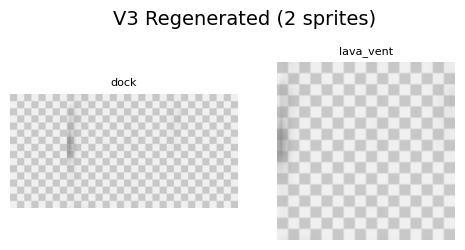

In [8]:
import matplotlib.pyplot as plt

# ─── Final quality scan ───
print('=== Final quality scan ===')
final_fails = scan_quality(out_dir)
if final_fails:
    print(f'\nWARNING: {len(final_fails)} still failing: {final_fails}')
    print('Consider manual review or further prompt tweaking.')
else:
    print('\nAll sprites pass quality check!')

# ─── Preview grid of regenerated items ───
regen_pngs = [out_dir / f'{n}.png' for n in to_regen if (out_dir / f'{n}.png').exists()]
if regen_pngs:
    cols = min(5, len(regen_pngs))
    rows = (len(regen_pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.atleast_2d(axes) if rows > 1 else np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis('off')
    for i, png in enumerate(regen_pngs):
        ax = axes[i // cols][i % cols]
        img = Image.open(png)
        # Checkerboard background for visibility
        w, h = img.size
        checker = np.zeros((h, w, 4), dtype=np.uint8)
        for y in range(h):
            for x in range(w):
                c = 200 if (x // 4 + y // 4) % 2 == 0 else 240
                checker[y, x] = [c, c, c, 255]
        bg = Image.fromarray(checker, 'RGBA')
        bg.paste(img, (0, 0), img)
        ax.imshow(bg)
        ax.set_title(png.stem.replace('deco_', ''), fontsize=8)
    plt.suptitle(f'V3 Regenerated ({len(regen_pngs)} sprites)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Nothing to preview.')

In [9]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'decorations'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['decorations'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/decorations_v3_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Manifest:
  decorations: 20

Zip: 42.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>